# Teoria da Decisão & Modelagem Preditiva: Lotofácil
### Estimação dos Próximos 15 Números através de 3 Métodos Analíticos
**Base de dados:** `loto_facil_asloterias_ate_concurso_3794_sorteio.xlsx`  
**Alvo:** Estimativa das 15 dezenas para o **Concurso 3795**  
**Referência Metodológica:** *Inferência Bayesiana e Teoria da Decisão* (Esteves, Izbicki e Stern)

---

## Estrutura do Estudo
Implementamos e comparamos **3 métodos analíticos distintos** ajustados especificamente para a dinâmica da **Lotofácil** (25 dezenas no volante, 15 sorteadas por concurso):

1. **Método 1 (Estatístico / Frequência Ponderada & Atraso):** Combina frequência com decaimento exponencial temporal com a métrica de atraso relativo (pressão de compensação/retorno à média empírica).
2. **Método 2 (Machine Learning Multi-label):** Modelo supervisionado (*Binary Relevance* com Regressão Logística L2 calibrada) alimentado por janelas móveis temporais multiescala e defasagens (*lags*), estritamente sem vazamento de dados (*lookahead bias*).
3. **Método 3 (Bayesiano & Teoria da Decisão):** Modelagem conjugada Beta-Binomial com priori informativa justa $\text{Beta}(6.0, 4.0)$ cuja esperança a priori reflete exatamente a probabilidade teórica neutra de cada bola:
   $$\mathbb{E}[\theta_i] = \frac{6.0}{6.0 + 4.0} = 0.6000 \quad \left(\frac{15}{25}\right)$$
   A escolha das 15 dezenas decorre da formalização do problema de decisão $(\mathcal{A}, \Theta, P, U)$ pela **Alternativa de Bayes** (maximização da utilidade esperada a posteriori de acertos).

In [1]:
import sys
import os

# Garante que o módulo mega_sena_models seja localizado a partir da raiz ou de notebooks/
for path_cand in ['.', '..', os.path.dirname(os.getcwd())]:
    if os.path.exists(os.path.join(path_cand, 'mega_sena_models.py')):
        abs_cand = os.path.abspath(path_cand)
        if abs_cand not in sys.path:
            sys.path.insert(0, abs_cand)
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mega_sena_models import (
    load_lottery_data,
    compute_delay_statistics,
    FrequencyDelayModel,
    MultiLabelMLModel,
    BayesianDecisionModel,
    run_all_lottery_methods
)

# Configurações de exibição
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 1000)
pd.set_option('display.precision', 5)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

EXCEL_PATH = 'loto_facil_asloterias_ate_concurso_3794_sorteio.xlsx'
df, binary_matrix, cfg = load_lottery_data(EXCEL_PATH, game='lotofacil')

print(f"Loteria: {cfg['name']} ({cfg['n_dezenas']} dezenas totais, {cfg['k']} dezenas por concurso)")
print(f"Total de concursos carregados: {len(df)}")
print(f"Primeiro concurso: {df.iloc[0]['Concurso']} ({df.iloc[0]['Data']})")
print(f"Último concurso: {df.iloc[-1]['Concurso']} ({df.iloc[-1]['Data']})")
print(f"Formato da matriz binária de ocorrências: {binary_matrix.shape}")

Loteria: Lotofácil (25 dezenas totais, 15 dezenas por concurso)
Total de concursos carregados: 3794
Primeiro concurso: 1 (29/09/2003)
Último concurso: 3794 (01/10/2026)
Formato da matriz binária de ocorrências: (3794, 25)


---
## Método 1: Abordagem Estatística (Frequência Ponderada & Atraso)

### Fundamentação
1. **Frequência Ponderada no Tempo ($f_{w, i}$):** Ponderação com decaimento exponencial $w_t = 2^{-(T - t) / 100}$, atribuindo maior sensibilidade aos sorteios recentes.
2. **Métrica de Atraso Relativo ($R_i = d_i / \mu_{gap, i}$):** Razão entre o atraso atual (concursos consecutivos sem sair) e o intervalo médio esperado entre aparições.
3. **Escore Padronizado Balanceado:** $S_i = 0.5 \cdot Z(f_{w, i}) + 0.5 \cdot Z(R_i)$.

Top 15 Método 1 (Balanceado): [1, 2, 3, 4, 5, 9, 11, 12, 15, 16, 21, 22, 23, 24, 25]
Top 15 Método 1 (Mais Atrasadas): [2, 6, 7, 8, 9, 10, 11, 13, 14, 16, 17, 19, 20, 22, 25]
Top 15 Método 1 (Mais Frequentes Recentes): [1, 3, 4, 5, 6, 9, 11, 12, 13, 14, 15, 21, 23, 24, 25]


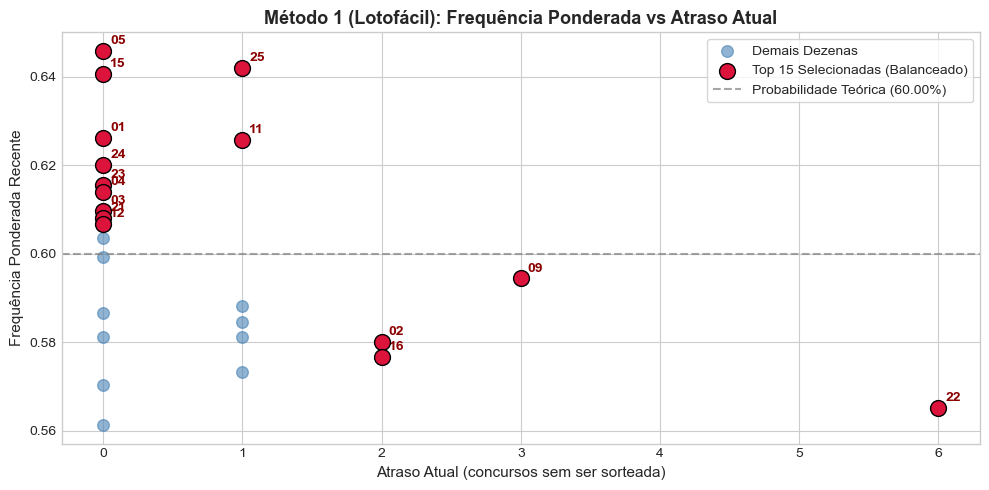

In [2]:
# Treinando o Método 1
m1 = FrequencyDelayModel(half_life=100.0, alpha=0.5)
m1.fit(binary_matrix)
df_m1 = m1.get_scores_df()

pred_m1_bal = m1.predict_top_k(15, strategy='balanced')
pred_m1_over = m1.predict_top_k(15, strategy='overdue')
pred_m1_mom = m1.predict_top_k(15, strategy='momentum')

print(f"Top 15 Método 1 (Balanceado): {pred_m1_bal}")
print(f"Top 15 Método 1 (Mais Atrasadas): {pred_m1_over}")
print(f"Top 15 Método 1 (Mais Frequentes Recentes): {pred_m1_mom}")

# Visualização: Atraso Atual vs Frequência Ponderada
fig, ax = plt.subplots(figsize=(10, 5))
selected_mask = df_m1['dezena'].isin(pred_m1_bal)

ax.scatter(df_m1.loc[~selected_mask, 'atraso_atual'], 
           df_m1.loc[~selected_mask, 'freq_ponderada'],
           c='steelblue', alpha=0.6, s=70, label='Demais Dezenas')

ax.scatter(df_m1.loc[selected_mask, 'atraso_atual'], 
           df_m1.loc[selected_mask, 'freq_ponderada'],
           c='crimson', edgecolors='black', s=130, zorder=5, label=f'Top 15 Selecionadas (Balanceado)')

for _, r in df_m1[selected_mask].iterrows():
    ax.annotate(f"{int(r['dezena']):02d}", 
                (r['atraso_atual'], r['freq_ponderada']),
                textcoords="offset points", xytext=(5, 5), fontweight='bold', color='darkred')

ax.set_title(f"Método 1 (Lotofácil): Frequência Ponderada vs Atraso Atual", fontsize=13, fontweight='bold')
ax.set_xlabel("Atraso Atual (concursos sem ser sorteada)", fontsize=11)
ax.set_ylabel("Frequência Ponderada Recente", fontsize=11)
ax.axhline(0.6, color='gray', linestyle='--', alpha=0.7, label=f'Probabilidade Teórica (60.00%)')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

---
## Método 2: Machine Learning Supervisionado Multi-label

### Engenharia de Atributos e Calibração
- Treina 25 classificadores independentes (*Binary Relevance*) com probabilidades calibradas via Regressão Logística L2.
- Utiliza janelas móveis passadas ($W \in [5, 10, 25, 50, 100]$), defasagens (*lags* 1 a 3) e métricas de atraso, estritamente sem vazamento de dados futuros (*zero data leakage*).
- As dezenas com maiores probabilidades calibradas no instante $T+1$ compõem a aposta de 15 dezenas.

Top 15 Método 2 (Machine Learning Calibrado): [3, 5, 7, 8, 9, 11, 12, 13, 14, 18, 19, 20, 22, 24, 25]


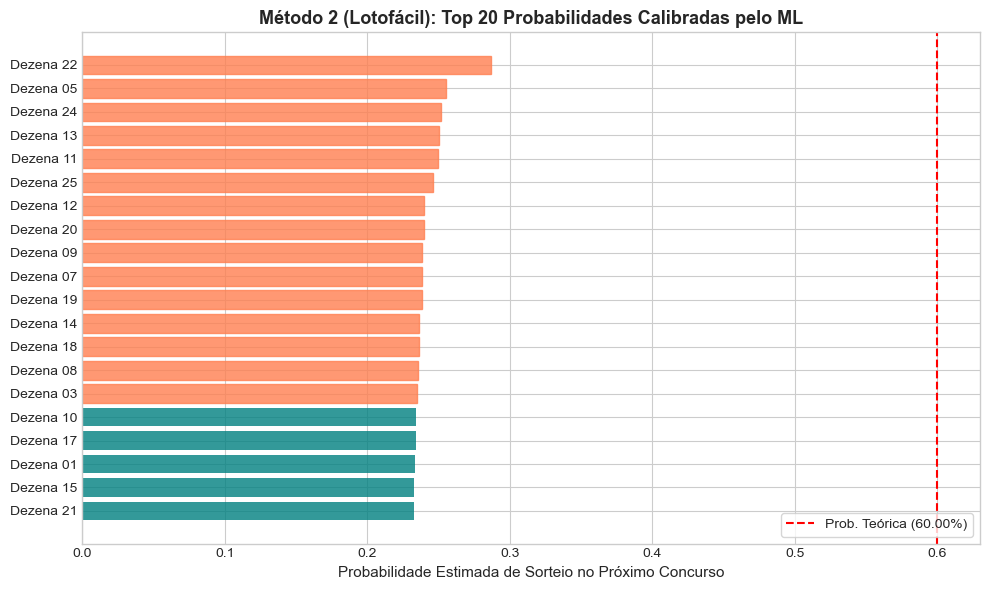

In [3]:
# Treinando o Método 2
m2 = MultiLabelMLModel(estimator='logistic_regression', random_state=42)
m2.fit(binary_matrix)
df_m2 = m2.get_probabilities_df()

pred_m2 = m2.predict_top_k(15)
print(f"Top 15 Método 2 (Machine Learning Calibrado): {pred_m2}")

# Visualização: Probabilidades Calibradas das Top Dezenas
top_display = min(20, 25)
top_df_m2 = df_m2.head(top_display).sort_values('probabilidade_calibrada_sorteio', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(np.arange(len(top_df_m2)), top_df_m2['probabilidade_calibrada_sorteio'], color='teal', alpha=0.8)

# Destaque para as top K escolhidas
for i, (_, row) in enumerate(top_df_m2.iterrows()):
    if int(row['dezena']) in pred_m2:
        bars[i].set_color('coral')

ax.set_yticks(np.arange(len(top_df_m2)))
ax.set_yticklabels([f"Dezena {int(d):02d}" for d in top_df_m2['dezena']], fontsize=10)
ax.axvline(0.6, color='red', linestyle='--', linewidth=1.5, label=f'Prob. Teórica (60.00%)')
ax.set_title(f"Método 2 (Lotofácil): Top {top_display} Probabilidades Calibradas pelo ML", fontsize=13, fontweight='bold')
ax.set_xlabel("Probabilidade Estimada de Sorteio no Próximo Concurso", fontsize=11)
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

---
## Método 3: Inferência Bayesiana & Teoria da Decisão

### 1. Conjugação Beta-Binomial (Capítulo 4 & 7 do Livro)
- **Priori Racional Justa:** $\theta_i \sim \text{Beta}(\alpha_0=6.0, \beta_0=4.0)$ com $\mathbb{E}[\theta_i] = 0.6000$.
- **Atualização a Posteriori Exata:**
  $$\theta_i \mid x_i \sim \text{Beta}(\alpha_0 + x_i, \beta_0 + n - x_i)$$
- **Esperança a Posteriori e Intervalo de Credibilidade de 95%:**
  $$\mathbb{E}[\theta_i \mid x_i] = \frac{\alpha_0 + x_i}{\alpha_0 + \beta_0 + n}$$

### 2. Teoria da Decisão (Capítulo 6 do Livro)
O problema de decisão $(\mathcal{A}, \Theta, P, U)$ busca selecionar a aposta $a = \{d_1, \dots, d_{15}\}$ que maximiza a utilidade esperada a posteriori:
$$\mathbb{E}[U(a, \mathbf{s}) \mid \text{dados}] = \sum_{i \in a} \mathbb{E}[\theta_i \mid x_i]$$
A **Alternativa de Bayes ótima** consiste em selecionar as **15 dezenas com as maiores esperanças a posteriori**.

Top 15 Decisão Ótima de Bayes (Conjugado Global): [1, 2, 3, 4, 5, 9, 10, 11, 12, 13, 14, 15, 20, 24, 25]
Top 15 Decisão Ótima de Bayes (Dinâmico Adaptativo): [1, 3, 4, 5, 6, 7, 9, 11, 12, 13, 15, 21, 23, 24, 25]


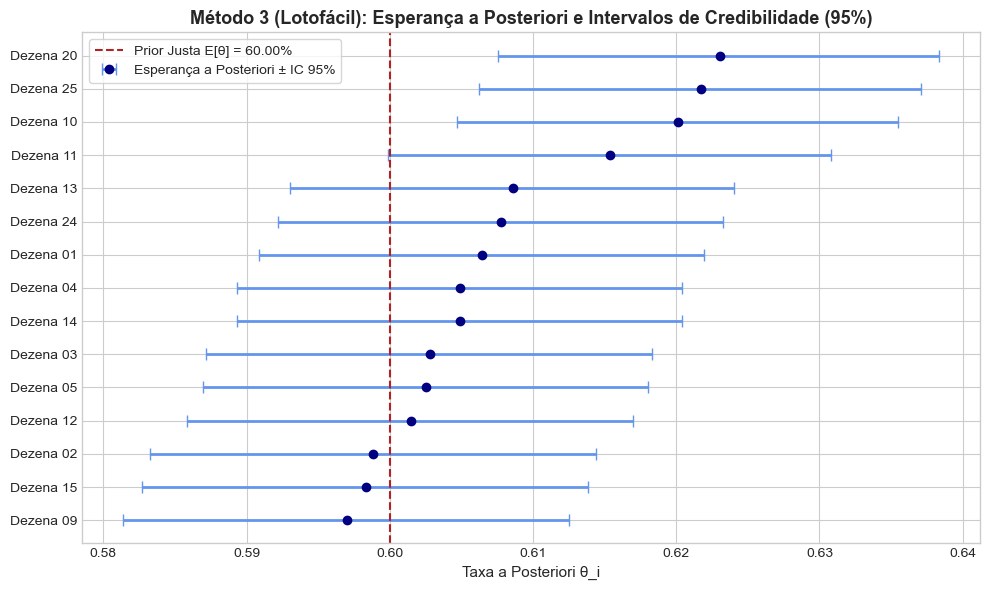

In [4]:
# 3a. Modelo Bayesiano Conjugado Global
m3_static = BayesianDecisionModel(alpha_0=6.0, beta_0=4.0)
m3_static.fit(binary_matrix)
df_m3 = m3_static.get_posterior_df()

pred_m3_static = m3_static.predict_top_k(15)
print(f"Top 15 Decisão Ótima de Bayes (Conjugado Global): {pred_m3_static}")

# 3b. Modelo Bayesiano Dinâmico Adaptativo (Decaimento Temporal)
m3_dyn = BayesianDecisionModel(alpha_0=6.0, beta_0=4.0, decay_half_life=150.0)
m3_dyn.fit(binary_matrix)
pred_m3_dyn = m3_dyn.predict_top_k(15)
print(f"Top 15 Decisão Ótima de Bayes (Dinâmico Adaptativo): {pred_m3_dyn}")

# Visualização: Intervalos de Credibilidade de 95%
n_show = min(15, 25)
df_ci = df_m3.head(n_show).copy()

fig, ax = plt.subplots(figsize=(10, 6))
y_positions = np.arange(len(df_ci))
ax.errorbar(df_ci['esperanca_posteriori'], y_positions,
            xerr=[df_ci['esperanca_posteriori'] - df_ci['ci_95_inf'],
                  df_ci['ci_95_sup'] - df_ci['esperanca_posteriori']],
            fmt='o', color='navy', ecolor='cornflowerblue', elinewidth=2, capsize=4,
            label='Esperança a Posteriori ± IC 95%')

ax.axvline(0.6, color='firebrick', linestyle='--', linewidth=1.5, label=f'Prior Justa E[θ] = 60.00%')
ax.set_yticks(y_positions)
ax.set_yticklabels([f"Dezena {int(d):02d}" for d in df_ci['dezena']], fontsize=10)
ax.set_title(f"Método 3 (Lotofácil): Esperança a Posteriori e Intervalos de Credibilidade (95%)", fontsize=13, fontweight='bold')
ax.set_xlabel("Taxa a Posteriori θ_i", fontsize=11)
ax.invert_yaxis()
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

---
## Comparação Consolidada dos 3 Métodos para o Concurso 3795
Abaixo apresentamos o quadro comparativo consolidado e a análise de consenso entre todos os modelos.

In [5]:
results = run_all_lottery_methods(EXCEL_PATH, game='lotofacil', next_concurso=3795)
comp_df = results['comparison_df']

print("=" * 85)
print(f"QUADRO RESUMO DE ESTIMATIVAS - LOTOFÁCIL (CONCURSO 3795)")
print("=" * 85)
for idx, row in comp_df.iterrows():
    print(f"{row['Metodo']:<50} : {row['Dezenas Previstas']}")
print("=" * 85)

# Consenso e contagem de votos
all_suggested = []
for k_model in ['Metodo 1 (Estatistico - Balanceado)', 
                'Metodo 2 (Machine Learning Multi-label Calibrado)', 
                'Metodo 3 (Bayesiano Conjugado Global)',
                'Metodo 3 (Bayesiano Dinamico Adaptativo)']:
    all_suggested.extend(results['predictions'][k_model])

freq_series = pd.Series(all_suggested).value_counts()
print(f"\nDezenas mais indicadas pelos modelos para o Concurso 3795:")
for dez, count in freq_series.items():
    if count >= 2:
        print(f"Dezena {dez:02d}: indicada por {count} abordagens")

QUADRO RESUMO DE ESTIMATIVAS - LOTOFÁCIL (CONCURSO 3795)
Metodo 1 (Estatistico - Balanceado)                : 01, 02, 03, 04, 05, 09, 11, 12, 15, 16, 21, 22, 23, 24, 25
Metodo 1 (Sub-estrategia Mais Atrasadas)           : 02, 06, 07, 08, 09, 10, 11, 13, 14, 16, 17, 19, 20, 22, 25
Metodo 1 (Sub-estrategia Mais Frequentes Recentes) : 01, 03, 04, 05, 06, 09, 11, 12, 13, 14, 15, 21, 23, 24, 25
Metodo 2 (Machine Learning Multi-label Calibrado)  : 03, 05, 07, 08, 09, 11, 12, 13, 14, 18, 19, 20, 22, 24, 25
Metodo 3 (Bayesiano Conjugado Global)              : 01, 02, 03, 04, 05, 09, 10, 11, 12, 13, 14, 15, 20, 24, 25
Metodo 3 (Bayesiano Dinamico Adaptativo)           : 01, 03, 04, 05, 06, 07, 09, 11, 12, 13, 15, 21, 23, 24, 25

Dezenas mais indicadas pelos modelos para o Concurso 3795:
Dezena 25: indicada por 4 abordagens
Dezena 03: indicada por 4 abordagens
Dezena 05: indicada por 4 abordagens
Dezena 09: indicada por 4 abordagens
Dezena 11: indicada por 4 abordagens
Dezena 12: indicada por 4 

---
## Considerações Críticas e Limitações Teóricas

1. **Hipótese de Aleatoriedade Estrita:**
   Do ponto de vista formal da probabilidade, a Lotofácil é sorteada por globos de precisão sem reposição. Sob a hipótese de jogo justo, a probabilidade teórica de cada dezena é rigorosamente uniforme:
   - Cada bola individual tem probabilidade teórica neutra de $60.00%$.
2. **Valor das Abordagens Analíticas:**
   - **Método 1:** Explora assimetrias amostrais momentâneas (frequência recente vs. atraso acumulado).
   - **Método 2:** Detecta correlações não-lineares e padrões multitemporais através de Machine Learning calibrado.
   - **Método 3:** Aplica o rigor analítico da **Inferência Bayesiana** (atualização racional de incertezas) e da **Teoria da Decisão** (maximização da utilidade esperada de Bayes).